In [1]:
from sklearn.ensemble import RandomForestRegressor
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

pd.options.mode.chained_assignment = None

%matplotlib inline

## 讀取資料

讀入訓練集（train.csv）、測試集（test.csv），
以及 Kaggle 提供的提交範例格式（sampleSubmission.csv）。

## 檢查資料狀況

使用 `.info()` 觀察欄位型態與是否有缺失值，
使用 `.describe()` 觀察數值欄位的統計分布。

觀察發現，train 和 test 皆無缺失值，

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submit = pd.read_csv('sampleSubmission.csv')

train.head(3)  # 測試，確認資料讀取成功

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [4]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   str    
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), str(1)
memory usage: 456.7 KB


In [5]:
train.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [6]:
test.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
count,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000
mean,2.493300,0.029108,0.685815,1.436778,20.620607,24.012865,64.125212,12.631157
std,1.091258,0.168123,0.464226,0.648390,8.059583,8.782741,19.293391,8.250151
min,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,16.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,49.000000,7.001500
50%,3.000000,0.000000,1.000000,1.000000,21.320000,25.000000,65.000000,11.001400
75%,3.000000,0.000000,1.000000,2.000000,27.060000,31.060000,81.000000,16.997900
max,4.000000,1.000000,1.000000,4.000000,40.180000,50.000000,100.000000,55.998600


## 排除離群值

count 欄位的中位數為 145，最大值卻高達 977，差距懸殊。  
以「與平均值差距超過 3 倍標準差」為門檻排除離群值，
排除後，訓練集筆數由 10886 筆降至 10739 筆。

In [7]:
print ("Shape Of The Before Ouliers:", train.shape)
train =train[np.abs 
             (train["count"]-train["count"].mean())
             <= (3*train["count"].std())
             ]
print ("Shape Of The After Ouliers:", train.shape)

Shape Of The Before Ouliers: (10886, 12)
Shape Of The After Ouliers: (10739, 12)


## 合併訓練集與測試集

先合併 train 與 test 一起處理時間特徵，並重新整理索引。

In [8]:
data = pd.concat([train, test])
data.reset_index(inplace=True, drop=True)

## 拆解時間特徵

原始 datetime 是文字格式，模型無法直接利用。
拆解出日期、小時、年份、星期幾、月份，作為獨立的數值特徵，方便模型學習時間相關的規律。

In [9]:
# 資料格式 "2011-01-01 00:00:00"
data["date"] = data.datetime.apply(lambda x : x.split()[0])
data["hour"] = data.datetime.apply(lambda x : x.split()[1].split(":")[0]).astype("int")
data["year"] = data.datetime.apply(lambda x : x.split()[0].split("-")[0])

# 把字串日期(如 "2011-01-01")解析成日期物件，再取出星期幾/月份
data["weekday"] = data['date'].apply(lambda dateString: datetime.strptime(dateString, "%Y-%m-%d").weekday()) 
data["month"] = data['date'].apply(lambda dateString: datetime.strptime(dateString, "%Y-%m-%d").month) 

data #檢查

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,year,weekday,month
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3.0,13.0,16.0,2011-01-01,0,2011,5,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8.0,32.0,40.0,2011-01-01,1,2011,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5.0,27.0,32.0,2011-01-01,2,2011,5,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3.0,10.0,13.0,2011-01-01,3,2011,5,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0.0,1.0,1.0,2011-01-01,4,2011,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17227,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN,2012-12-31,19,2012,0,12
17228,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN,2012-12-31,20,2012,0,12
17229,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,NaN,NaN,2012-12-31,21,2012,0,12
17230,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,NaN,NaN,2012-12-31,22,2012,0,12


## 檢視數值特徵的分布 (溫度、體感溫度、濕度、風速)

發現風速為 0 的資料異常地多，且風速接近 0（約 6、7 以內）
幾乎沒有出現，推測風速 0 可能是資料缺失時被統一補值，而非真實風速為 0。  
後續需要重新估計這些值。

[Text(0.5, 0, 'windspeed'), Text(0.5, 1.0, 'distribution of windspeed')]

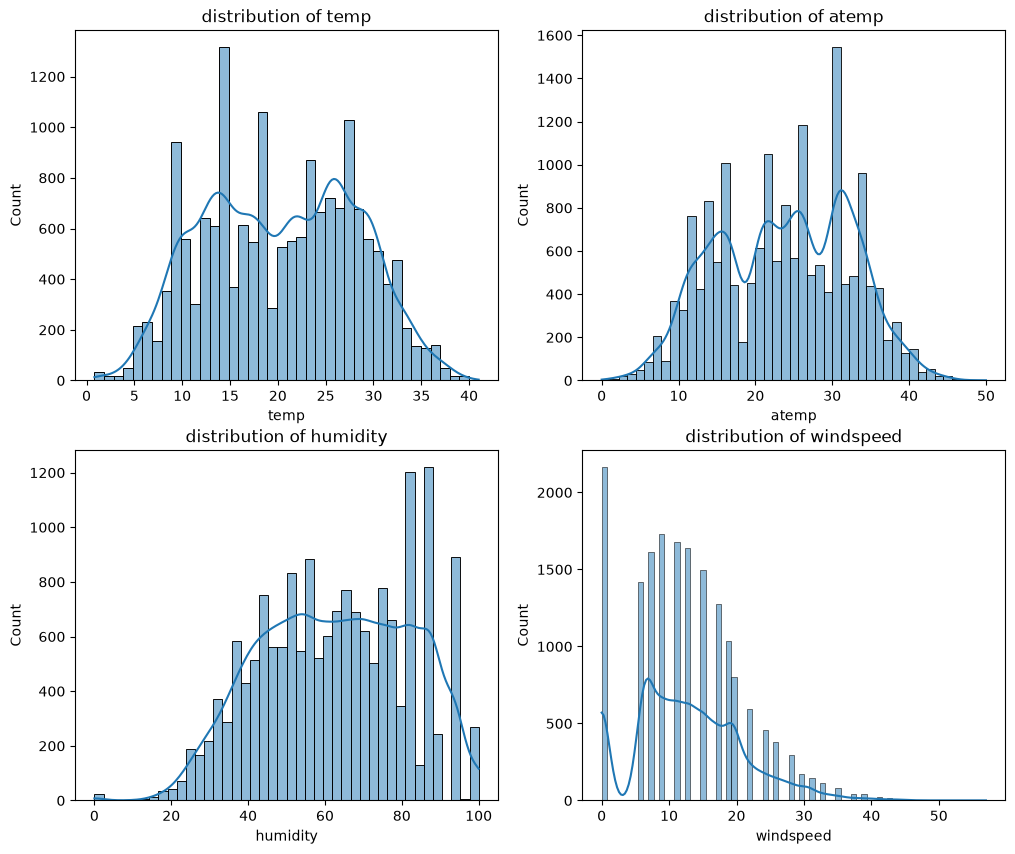

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_size_inches(12,10)
sns.histplot(data["temp"], ax=axes[0][0], kde=True)
sns.histplot(data["atemp"], ax=axes[0][1], kde=True)
sns.histplot(data["humidity"], ax=axes[1][0], kde=True)
sns.histplot(data["windspeed"], ax=axes[1][1], kde=True)

axes[0][0].set(xlabel='temp',title="distribution of temp")
axes[0][1].set(xlabel='atemp',title="distribution of atemp")
axes[1][0].set(xlabel='humidity',title="distribution of humidity")
axes[1][1].set(xlabel='windspeed',title="distribution of windspeed")

## 使用隨機森林預測風速為 0 的資料

風速為 0 的資料異常地多，推測是缺失值被補為 0，而非真實風速。  
用風速不為 0 的資料訓練隨機森林迴歸模型，重新預測這些風速值。

In [11]:
# 找出風速等於0的資料(要被預測、填補)
dataWind0 = data[data["windspeed"]==0]
# 找出風速不等於0的資料(「正常」的,用來訓練模型)
dataWindNot0 = data[data["windspeed"]!=0]

#建立一個隨機森林迴歸模型
rfModel_wind = RandomForestRegressor(n_estimators=1000, random_state=42)
# 列出要用哪些特徵來預測風速
windColumns = ["season","weather","humidity","month","temp","year","atemp"]
# 用風速不為0的資料，訓練模型。.fit(特徵, 答案)
rfModel_wind.fit(dataWindNot0[windColumns], dataWindNot0["windspeed"])

# 對「風速等於零」的乘客，逐一預測出來
wind0Values = rfModel_wind.predict(X= dataWind0[windColumns])
# 把預測出來的風速，填回「風速」欄位
dataWind0.loc[:,"windspeed"] = wind0Values
data = pd.concat([dataWindNot0, dataWind0])
data.reset_index(inplace=True, drop=True)

<Axes: xlabel='windspeed', ylabel='Count'>

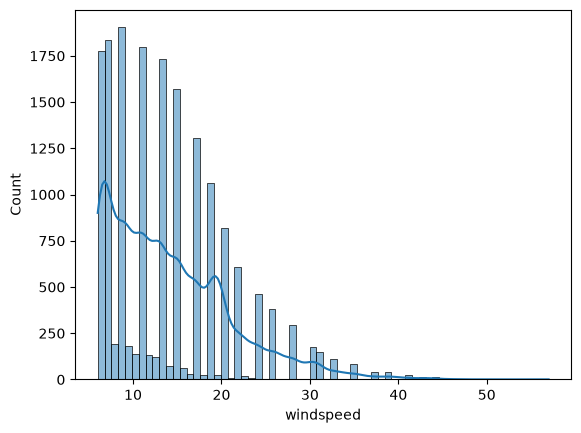

In [12]:
sns.histplot(data["windspeed"], kde=True)

## 拆分回訓練集與測試集，並對 count 取對數。

count 分布嚴重右偏，透過取對數（log）轉換，使其更接近常態分布，
同時保留 datetime 供輸出使用，移除 casual、registered 等答案相關欄位。

In [13]:
dataTrain = data[pd.notnull(data['count'])].sort_values(by=["datetime"])
dataTest = data[~pd.notnull(data['count'])].sort_values(by=["datetime"])
datetimecol = dataTest['datetime'] # 保留測試集的 datetime，供最終輸出使用
yLabels = dataTrain["count"]   # 取log前
yLabelsLog = np.log(yLabels)   # 取log後

In [14]:
dropFeatures = ['casual',"count","datetime","date","registered"]
dataTrain  = dataTrain.drop(dropFeatures,axis=1)
dataTest  = dataTest.drop(dropFeatures,axis=1)

## 比較 count 取對數前後的分布

可看出偏斜程度明顯改善，更接近常態分布

[Text(0.5, 0, 'count (log)'),
 Text(0.5, 1.0, 'distribution of count (after log)')]

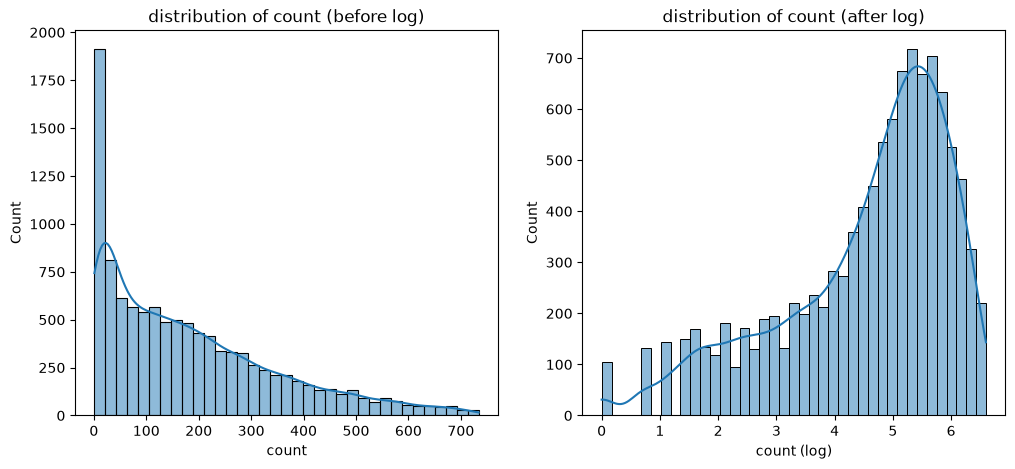

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(12, 5)

sns.histplot(yLabels, ax=axes[0], kde=True)
sns.histplot(yLabelsLog, ax=axes[1], kde=True)

axes[0].set(xlabel='count', title="distribution of count (before log)")
axes[1].set(xlabel='count (log)', title="distribution of count (after log)")

## 訓練模型並產生提交檔案

使用取對數後的 count 訓練隨機森林迴歸模型，對測試集進行預測。  
並計算訓練集上的 RMSE，作為模型表現的初步檢查。

In [16]:
rfModel = RandomForestRegressor(n_estimators=1000,random_state=42)
rfModel.fit(dataTrain,yLabelsLog)

# 自我檢查：計算訓練集上的 RMSE 
# 均方根誤差：預測值跟真實值，平均差了多少
from sklearn.metrics import mean_squared_error

preds = rfModel.predict(X=dataTrain)
rmse = np.sqrt(mean_squared_error(yLabelsLog, preds))
print(f"訓練集上的 RMSE（log尺度）: {rmse:.4f}")

訓練集上的 RMSE（log尺度）: 0.1209


## 產生提交檔案

因訓練時使用 log 轉換，預測結果需用 exp() 轉換回原始數值，
並將負值修正為 0（租借數量不可能為負）。  
最後組裝成 Kaggle 要求格式的提交檔案。

In [17]:
predsTest = rfModel.predict(X=dataTest)

# 打造提交用的表格
submission = pd.DataFrame({
    "datetime": datetimecol,
    # 用 exp() 把 log 過的預測值轉回原始數值，並將負值修正為 0
    "count": [max(0, x) for x in np.exp(predsTest)]
})

submission.to_csv('bike_predictions_RF.csv', index=False)